# Choosing k for the `cluster` labeling strategy

Generic and species-agnostic. Supports both a single input file and a
merged, multi-source case (set exactly one of `INPUT_TABLE` /
`MERGE_MANIFEST` below) -- so real multi-condition k-selection no longer
needs a hand-written throwaway script, it uses the same manifest format
`scripts/run_pipeline.py --merge-manifest` does.

This notebook is a PRE-labeling step: it exists to help pick a
defensible `n_clusters` before calling `labelers.cluster()` for real,
either directly or via the CLI. It never writes anything to disk.

Mirrors the workflow taught in the lab's own hierarchical-clustering
material (2023-DG-DataProcessing-11): inspect the raw distribution, run
an elbow curve and silhouette-score curve across a range of k, pick a
candidate, check that candidate's per-sample silhouette coefficients,
look at the dendrogram, and (added here) a real clustermap showing what
the chosen clusters actually look like against the data. Choosing k is
a human judgment call informed by these diagnostics, not something this
notebook decides automatically.

In [ ]:
# # ---------------------------------------------------------------------------
# # Configuration -- the only cell that needs editing for a different dataset.
# # Everything below is generic.
# # ---------------------------------------------------------------------------

# # Set EXACTLY ONE of these two, leave the other as None.

# # Single-file case: path to a gene-level TSV (plain or .gz).
# INPUT_TABLE = "/mnt/f/RA/Downstream/Project1_polysomelongread_PR/CR_3D.PR.gene_data.tsv.gz"

# # Merged, multi-source case: path to a plain-text, INI-style manifest,
# # same format as `scripts/run_pipeline.py --merge-manifest`. Example:
# #   [cond_3D]
# #   path = data/raw/CR_3D.gene_data.tsv.gz
# #   value_col = PR_gene
# #
# #   [cond_6D]
# #   path = data/raw/CR_6D.gene_data.tsv.gz
# #   value_col = PR_gene
# MERGE_MANIFEST = None  # e.g. "../merge_pr_gene.txt"

# ID_COL = "gene_id"
# STRIP_ID_SUFFIX = r"\.v\d+\.\d+$"   # set to None if IDs need no normalization
# EXCLUDE_IDS = ["gene:Standard-R-luc"]

# # For INPUT_TABLE: real column name(s) in that file.
# # For MERGE_MANIFEST: must match the manifest's [section] names.
# # One or more columns -- a single column is 1D clustering, several is a
# # joint/multi-condition clustering.
# METRIC_COLS = ["PR_gene"]

# MAX_K_ELBOW = 15
# K_RANGE_SILHOUETTE = range(2, 16)

# # Threshold for the uninformative-row PREVIEW below (not applied
# # automatically). Set to None to skip that section entirely.
# DROP_UNINFORMATIVE_THRESH = 0

In [41]:
INPUT_TABLE = "/mnt/f/RA/Downstream/Project1_polysomelongread_PR/CR_3D.PR.gene_data.tsv.gz"
MERGE_MANIFEST = None

ID_COL = "gene_id"
STRIP_ID_SUFFIX = r"\.v\d+\.\d+$"
EXCLUDE_IDS = ["gene:Standard-R-luc"]

METRIC_COLS = ["PR_gene"]

MAX_K_ELBOW = 15
K_RANGE_SILHOUETTE = range(2, 16)

DROP_UNINFORMATIVE_THRESH = 0

In [42]:
INPUT_TABLE = None
MERGE_MANIFEST = "merge_pr_gene_notebook.txt"

ID_COL = "gene_id"
STRIP_ID_SUFFIX = r"\.v\d+\.\d+$"
EXCLUDE_IDS = ["gene:Standard-R-luc"]

METRIC_COLS = ["cond_3D", "cond_6D"]

MAX_K_ELBOW = 15
K_RANGE_SILHOUETTE = range(2, 16)

DROP_UNINFORMATIVE_THRESH = 0

In [43]:
import re
import gzip
import sys, os

_cwd = os.getcwd()
while not os.path.isdir(os.path.join(_cwd, "labelers")) and os.path.dirname(_cwd) != _cwd:
    _cwd = os.path.dirname(_cwd)
sys.path.insert(0, _cwd)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from scipy import stats as scipy_stats

from labelers.labelers import elbow_curve, silhouette_scores, sample_silhouette, cluster
from filters.population import drop_uninformative_for_clustering
from dataprep.merge_tables import merge_gene_tables
from scripts.run_pipeline import read_merge_manifest

assert (INPUT_TABLE is None) != (MERGE_MANIFEST is None), (
    "Set exactly one of INPUT_TABLE or MERGE_MANIFEST above, not both, not neither."
)

if MERGE_MANIFEST:
    sources = read_merge_manifest(MERGE_MANIFEST)
    df = merge_gene_tables(sources, id_col=ID_COL, how="inner")
    print(f"Loaded {len(df)} genes (merged from {MERGE_MANIFEST}, "
          f"{len(sources)} sources, inner join)")
else:
    opener = gzip.open if INPUT_TABLE.endswith(".gz") else open
    with opener(INPUT_TABLE, "rt") as f:
        df = pd.read_csv(f, sep="\t", comment="#")
    print(f"Loaded {len(df)} genes from {INPUT_TABLE}")

if STRIP_ID_SUFFIX:
    df[ID_COL] = df[ID_COL].apply(lambda g: re.sub(STRIP_ID_SUFFIX, "", g))
if EXCLUDE_IDS:
    df = df[~df[ID_COL].isin(EXCLUDE_IDS)]
df = df.dropna(subset=METRIC_COLS)

print(f"After ID normalization / exclusion / dropna: {len(df)} genes")
print(f"Clustering on: {METRIC_COLS}")
df[METRIC_COLS].describe()

Loaded 2659 genes (merged from merge_pr_gene_notebook.txt, 2 sources, inner join)
After ID normalization / exclusion / dropna: 2658 genes
Clustering on: ['cond_3D', 'cond_6D']


,cond_3D,cond_6D
count,2658.000000,2658.000000
mean,0.913594,0.925298
std,0.585831,0.609227
min,0.000000,0.000000
25%,0.648515,0.634718
50%,0.851125,0.869769
75%,1.054740,1.084958
max,7.504249,9.510427


## Uninformative-row preview

A PREVIEW only -- `df` below is not filtered yet. Genes tied at exactly
the same floor value across every clustering column collapse to
identical points after the Yeo-Johnson + Z-score transform, and can
mechanically produce a spuriously "perfect" cluster (a real,
confirmed artifact, see `docs/examples/chlamydomonas.md`). If this
count is large, watch for a suspiciously perfect mean/min silhouette
in the per-sample silhouette step further down -- that is the signal
to actually apply the filter, not this preview number alone.

This is a fix for a clustering-tool mismatch, not a claim these genes
lack real biology: pair any use of this filter with a companion
`boolean_flag`/`explicit_threshold` GO run on the same population to
test the excluded genes on their own terms, see
`filters/population.py`'s docstring for the full reasoning.

In [44]:
if DROP_UNINFORMATIVE_THRESH is not None:
    n_before = len(df)
    would_keep = drop_uninformative_for_clustering(df, METRIC_COLS, thresh=DROP_UNINFORMATIVE_THRESH)
    n_dropped = n_before - len(would_keep)
    print(f"Genes with ALL of {METRIC_COLS} <= {DROP_UNINFORMATIVE_THRESH}: "
          f"{n_dropped} ({n_dropped / n_before:.1%} of {n_before})")
else:
    print("DROP_UNINFORMATIVE_THRESH is None, skipping the uninformative-row preview.")

Genes with ALL of ['cond_3D', 'cond_6D'] <= 0: 42 (1.6% of 2658)


## Apply the uninformative-row filter (optional)

Off by default. Set `APPLY_DROP_UNINFORMATIVE = True` below only after
reviewing the preview above and, ideally, seeing a suspicious artifact
in the per-sample silhouette step further down -- don't apply this
preemptively just because the preview count is nonzero.

In [45]:
APPLY_DROP_UNINFORMATIVE = False

if APPLY_DROP_UNINFORMATIVE:
    n_before = len(df)
    df = drop_uninformative_for_clustering(df, METRIC_COLS, thresh=DROP_UNINFORMATIVE_THRESH)
    print(f"Applied: {n_before} -> {len(df)} genes")
else:
    print("Not applied -- diagnostics below use the full population.")

Not applied -- diagnostics below use the full population.


## Raw distribution

Sanity check, not a decision point: `labelers.cluster()` always applies
a Yeo-Johnson transform (handles negative/zero values, unlike a plain
log transform). Heavily skewed or multimodal raw data here is useful
context for interpreting the elbow/silhouette plots below.

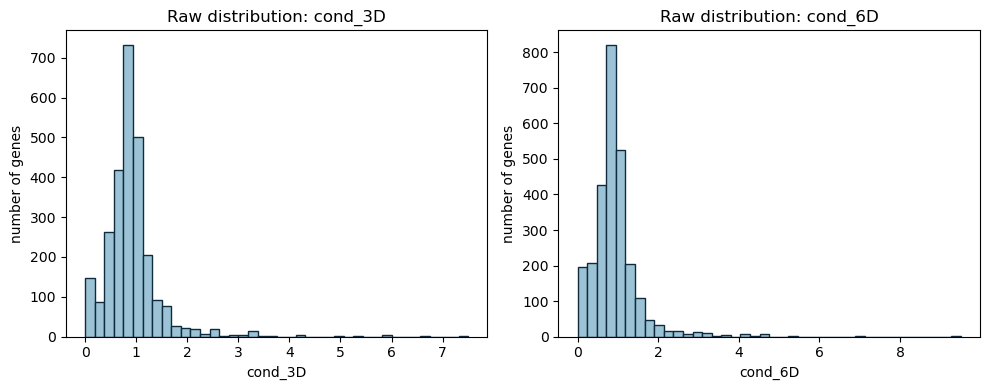

In [46]:
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(5 * len(METRIC_COLS), 4), squeeze=False)
for ax, col in zip(axes[0], METRIC_COLS):
    ax.hist(df[col], bins=40, color="#9CC3D5", edgecolor="#0F2A3D")
    ax.set_xlabel(col)
    ax.set_ylabel("number of genes")
    ax.set_title(f"Raw distribution: {col}")
fig.tight_layout()
plt.show()

## Elbow curve

Within-cluster sum of squared errors (WSS) versus k. Look for the point
where the curve stops dropping sharply and starts to flatten -- a
candidate k, not a computed answer.

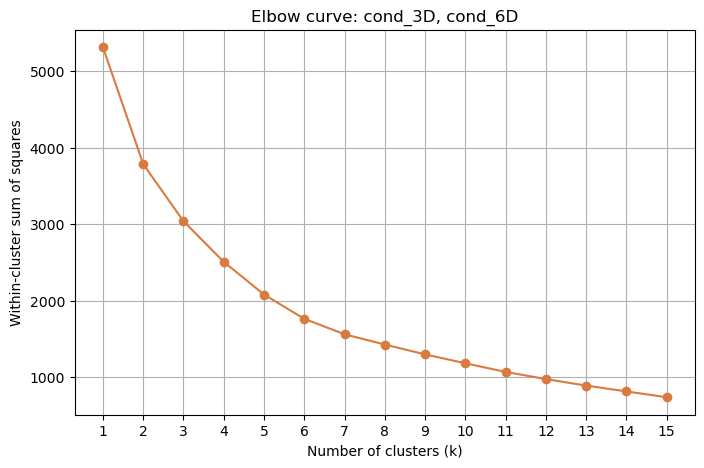

In [47]:
k_list, wss_list = elbow_curve(df, METRIC_COLS, max_k=MAX_K_ELBOW)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_list, wss_list, marker="o", color="#D97B3F")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-cluster sum of squares")
ax.set_title(f"Elbow curve: {', '.join(METRIC_COLS)}")
ax.set_xticks(k_list)
ax.grid(True)
plt.show()

## Silhouette score across k

A second, independent diagnostic. Higher is better-separated. Used
alongside the elbow curve, not instead of it -- the two can disagree,
which is itself useful information, not a bug.

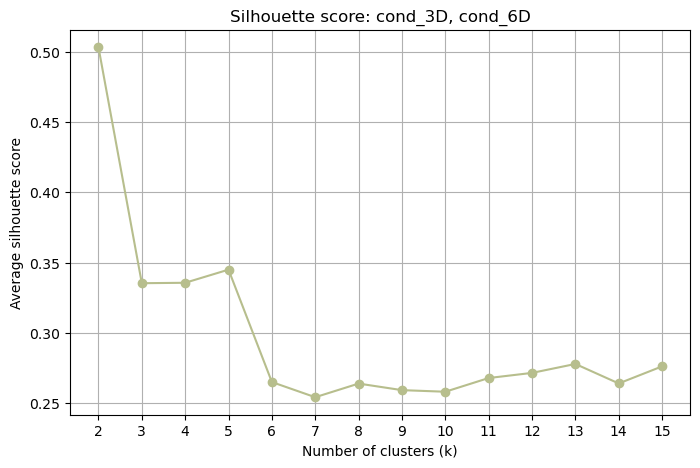

Top 5 candidate k by silhouette score:


,k,silhouette_score
0,2,0.503294
3,5,0.344979
2,4,0.335635
1,3,0.335331
11,13,0.277855


In [48]:
k_list_s, score_list = silhouette_scores(df, METRIC_COLS, k_range=K_RANGE_SILHOUETTE)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_list_s, score_list, marker="o", color="#B7BE8D")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Average silhouette score")
ax.set_title(f"Silhouette score: {', '.join(METRIC_COLS)}")
ax.set_xticks(k_list_s)
ax.grid(True)
plt.show()

score_table = pd.DataFrame({"k": k_list_s, "silhouette_score": score_list})
score_table = score_table.sort_values("silhouette_score", ascending=False)
print("Top 5 candidate k by silhouette score:")
display(score_table.head(5))

## Candidate k

Set this after looking at both plots above. A deliberate human decision,
not the output of a formula -- see the cells below for how to check
whether this specific choice actually holds up.

In [65]:
CANDIDATE_K = 7  # <-- set based on the elbow curve and silhouette score above

## Per-sample silhouette at the candidate k

Checks whether THIS split is well separated, not just whether its
average score looked good. Values near 1 = good fit, near 0 =
borderline, negative = likely misassigned. **A cluster with a mean/min
silhouette suspiciously at or near exactly 1.0 is the specific signal
to check the uninformative-row preview above and consider applying that
filter** -- this is a real, confirmed artifact pattern, not a
hypothetical concern.

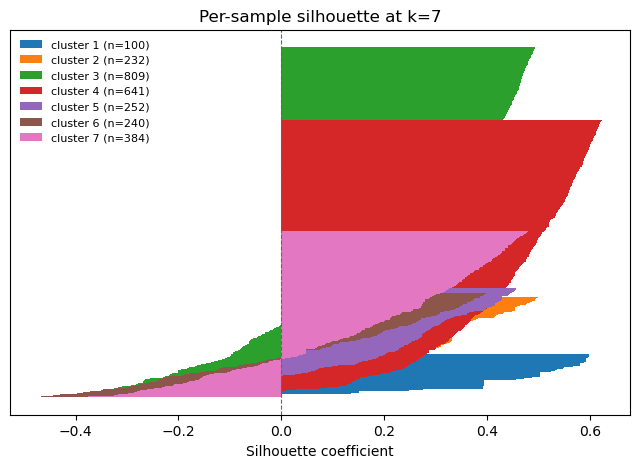

Per-cluster summary:


,count,mean,min
cluster,,,
1,100,0.427225,-0.267513
2,232,0.212937,-0.308667
3,809,0.207884,-0.408796
4,641,0.437833,-0.189399
5,252,0.203633,-0.263022
6,240,0.058138,-0.472839
7,384,0.180700,-0.385105


In [66]:
sil_df = sample_silhouette(df, METRIC_COLS, n_clusters=CANDIDATE_K)

fig, ax = plt.subplots(figsize=(8, 5))
for cluster_id in sorted(sil_df["cluster"].unique()):
    vals = sil_df.loc[sil_df["cluster"] == cluster_id, "silhouette"].sort_values()
    ax.barh(range(len(vals)), vals, left=0, height=1.0,
            label=f"cluster {cluster_id} (n={len(vals)})")
ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([])
ax.set_title(f"Per-sample silhouette at k={CANDIDATE_K}")
ax.legend(frameon=False, fontsize=8)
plt.show()

print("Per-cluster summary:")
summary = sil_df.groupby("cluster")["silhouette"].agg(["count", "mean", "min"])
display(summary)

suspicious = summary[(summary["mean"] >= 0.999) & (summary["min"] >= 0.999)]
if len(suspicious):
    print(f"\nWARNING: cluster(s) {list(suspicious.index)} have mean AND min silhouette "
          f"essentially exactly 1.0 -- this is the tied-value artifact pattern, not real "
          f"structure. Check the uninformative-row preview above before trusting this k.")

## Dendrogram

Colored to match `CANDIDATE_K` specifically (scipy's own default
`color_threshold` has no relationship to any chosen k and will
generally NOT match it).

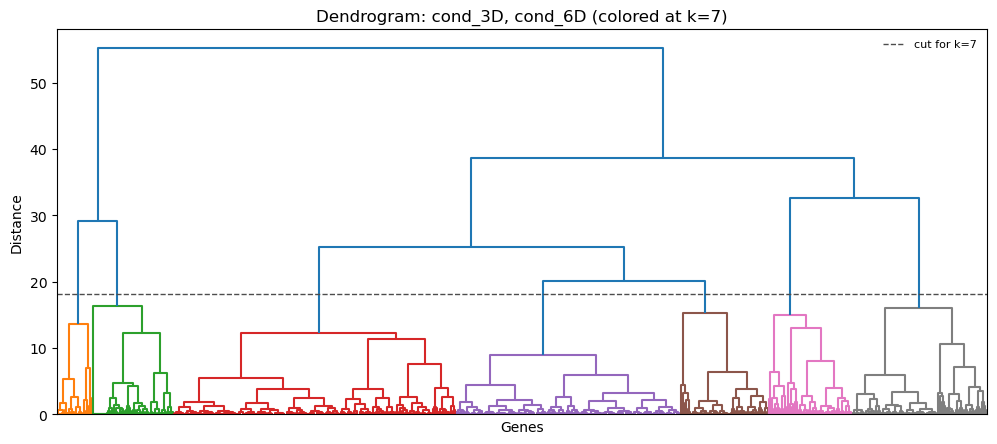

In [67]:
data = df[METRIC_COLS].apply(lambda c: scipy_stats.yeojohnson(c)[0])
z = (data - data.mean()) / data.std()
link = linkage(pdist(z.values, metric="euclidean"), method="ward")

merge_dists = sorted(link[:, 2], reverse=True)
if CANDIDATE_K > 1:
    color_threshold = (merge_dists[CANDIDATE_K - 2] + merge_dists[CANDIDATE_K - 1]) / 2
else:
    color_threshold = merge_dists[0] + 1

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(link, ax=ax, no_labels=True, color_threshold=color_threshold)
ax.axhline(color_threshold, color="0.3", linestyle="--", linewidth=1,
           label=f"cut for k={CANDIDATE_K}")
ax.set_xlabel("Genes")
ax.set_ylabel("Distance")
ax.set_title(f"Dendrogram: {', '.join(METRIC_COLS)} (colored at k={CANDIDATE_K})")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Clustermap

Heatmap of the transformed values, with a row dendrogram (genes) and,
row colors marking each gene's `CANDIDATE_K` cluster assignment.
Column clustering is only meaningful with 3 or more columns -- with 1
or 2, there is nothing for a column-side dendrogram to meaningfully
compare, so columns are shown in their given order instead rather than
silently forced into a dendrogram that would not mean anything.

Column clustering: disabled (2 column(s) -- need >= 3 for column clustering to be meaningful)


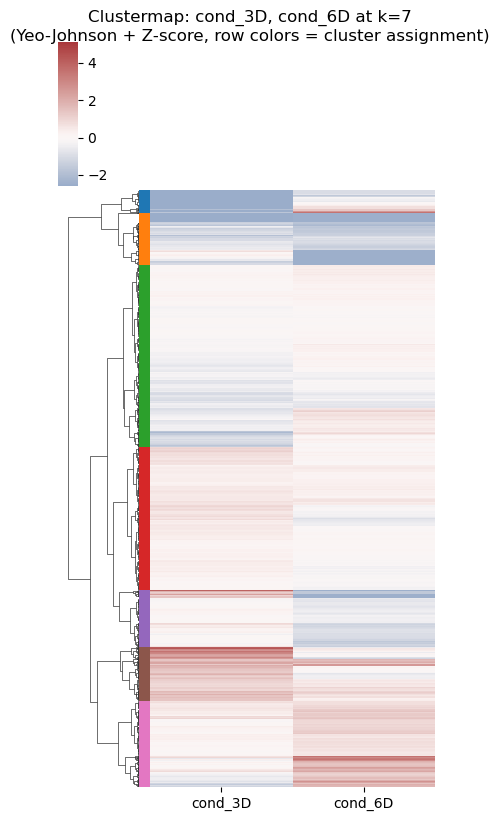

In [68]:
labeled = cluster(df, METRIC_COLS, n_clusters=CANDIDATE_K)
cluster_ids = labeled["class"]

palette = sns.color_palette("tab10", n_colors=cluster_ids.nunique())
lut = dict(zip(sorted(cluster_ids.unique(), key=int), palette))
row_colors = cluster_ids.map(lut)

cluster_col_axis = len(METRIC_COLS) >= 3
print(f"Column clustering: {'enabled' if cluster_col_axis else 'disabled'} "
      f"({len(METRIC_COLS)} column(s) -- need >= 3 for column clustering to be meaningful)")

g = sns.clustermap(
    z,
    method="ward", metric="euclidean",
    row_cluster=True, col_cluster=cluster_col_axis,
    row_colors=row_colors.values,
    cmap="vlag", center=0,
    yticklabels=False,
    figsize=(max(4, len(METRIC_COLS) * 1.8), 8),
)
g.fig.suptitle(f"Clustermap: {', '.join(METRIC_COLS)} at k={CANDIDATE_K}\n"
               f"(Yeo-Johnson + Z-score, row colors = cluster assignment)", y=1.02)
plt.show()

## Next step

Once `CANDIDATE_K` above is settled, run the real labeling through the
CLI. Single-file case:

```bash
python scripts/run_pipeline.py \
    --input-table <same path as INPUT_TABLE above> \
    --godb <path to .godb> \
    --metric-col <same as METRIC_COLS> \
    --label-strategy cluster --n-clusters <CANDIDATE_K> \
    --output-dir results/GO \
    --dataset-name <run name>
```

Merged case:

```bash
python scripts/run_pipeline.py \
    --merge-manifest <same path as MERGE_MANIFEST above> \
    --godb <path to .godb> \
    --metric-col <same section names as METRIC_COLS> \
    --label-strategy cluster --n-clusters <CANDIDATE_K> \
    --output-dir results/GO \
    --dataset-name <run name>
```

If `APPLY_DROP_UNINFORMATIVE` was used above, add `--drop-uninformative`
(and `--drop-uninformative-thresh` if not 0) to the command, AND run a
companion `--label-strategy boolean_flag` or `explicit_threshold` pass
on the excluded genes separately -- see the uninformative-row preview
section above for why.

This notebook never writes anything to disk, results only exist as an
in-memory record of the decision process, the CLI run above is what
produces real, versioned output files.